# EDA: DermaMNIST

Dermatoscopia, sete tipos de lesão de pele, RGB. Dez vezes mais dados que o
BreastMNIST, com cor e desbalanço de outra ordem de grandeza.

Consome `results/`. Não produz artefato.

In [1]:
RAIZ <- "../../results/_smoke"
DATASET <- "medmnist-dermamnist-28"

suppressMessages(devtools::load_all("../../analysis", quiet = TRUE))
suppressMessages({
  library(ggplot2)
  library(dplyr)
  library(tidyr)
})
options(repr.plot.width = 9.5, repr.plot.height = 5)

eda <- read_dataset_eda(DATASET, RAIZ)
s <- eda$summary
ex <- eda$examples
treino <- filter(ex, split == "train")
feats <- c("mean_intensity", "std_intensity", "nonzero_frac")

## 1. O que há na caixa

In [2]:
data.frame(
  campo = c("classes", "canais", "resolução", "treino", "validação", "teste"),
  valor = c(
    s$num_classes, s$in_channels, paste(s$resolution, collapse = "x"),
    s$n_examples$train, s$n_examples$val, s$n_examples$test
  )
)

campo,valor
<chr>,<chr>
classes,7
canais,3
resolução,28x28
treino,7007
validação,1003
teste,2005


## 2. O desbalanço domina tudo

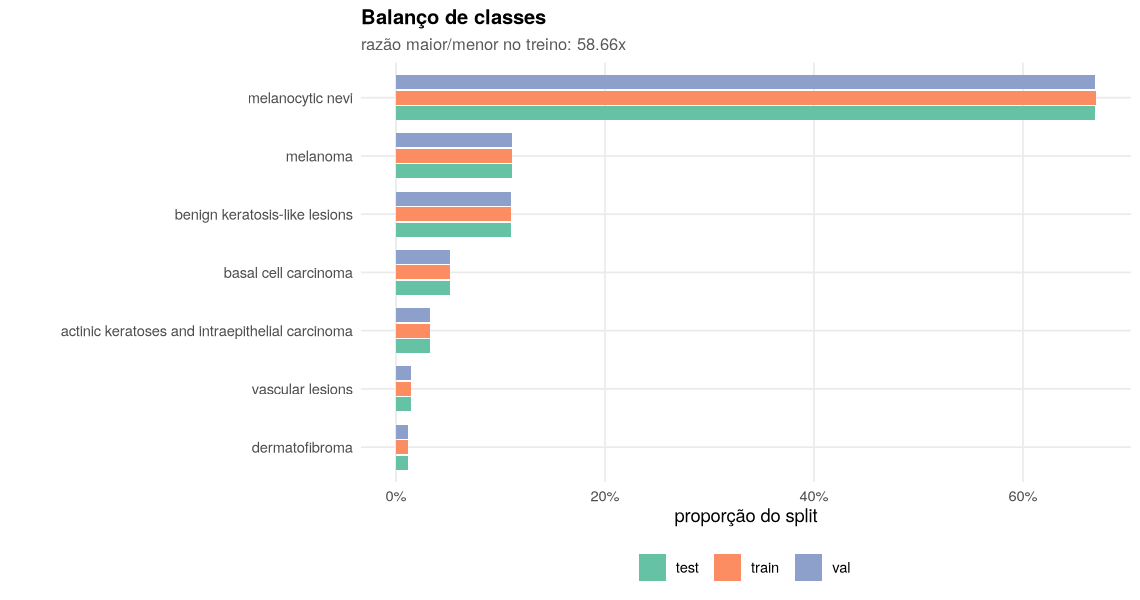

In [3]:
plot_class_balance(eda)

In [4]:
freq <- count(treino, class_name) |> mutate(p = n / sum(n)) |> arrange(desc(n))
print(as.data.frame(mutate(freq, p = sprintf("%.1f%%", 100 * p))))

cat(sprintf("\ndesbalanço maior/menor: %.1fx\n", s$train_imbalance_ratio))
cat(sprintf("prever sempre '%s': %.1f%% de acurácia\n", freq$class_name[1], 100 * freq$p[1]))
cat(sprintf("classe mais rara: '%s' com %d exemplos de treino\n",
            freq$class_name[nrow(freq)], freq$n[nrow(freq)]))

                                       class_name    n     p
1                                melanocytic nevi 4693 67.0%
2                                        melanoma  779 11.1%
3                   benign keratosis-like lesions  769 11.0%
4                            basal cell carcinoma  359  5.1%
5 actinic keratoses and intraepithelial carcinoma  228  3.3%
6                                vascular lesions   99  1.4%
7                                  dermatofibroma   80  1.1%



desbalanço maior/menor: 58.7x


prever sempre 'melanocytic nevi': 67.0% de acurácia


classe mais rara: 'dermatofibroma' com 80 exemplos de treino


**58,7x de desbalanço.** Uma classe ocupa dois terços do total.

**Piso de 67%.** Sempre responder "melanocytic nevi" reporta 67% de acurácia.
Acurácia sozinha não distingue isso de um modelo que aprendeu.

**80 exemplos na classe mais rara.** É problema de dado, não de modelo: nenhuma
arquitetura ou learning rate compensa 80 exemplos de dermatofibroma, e é nessa
classe que o recall vai ser pior.

In [5]:
# Quantos exemplos de TESTE cada classe tem? É isso que limita a precisão com que
# o recall dela pode ser estimado.
teste <- filter(ex, split == "test")
count(teste, class_name) |>
  arrange(n) |>
  mutate(
    `1 erro vale` = sprintf("%.1f pp", 100 / n),
    `IC95% a 70%` = sapply(n, function(k) {
      ci <- prop.test(round(0.7 * k), k)$conf.int
      sprintf("%.0f pp", 100 * (ci[2] - ci[1]))
    })
  ) |>
  as.data.frame()

class_name,n,1 erro vale,IC95% a 70%
<chr>,<int>,<chr>,<chr>
dermatofibroma,23,4.3 pp,39 pp
vascular lesions,29,3.4 pp,35 pp
actinic keratoses and intraepithelial carcinoma,66,1.5 pp,23 pp
basal cell carcinoma,103,1.0 pp,18 pp
benign keratosis-like lesions,220,0.5 pp,12 pp
melanoma,223,0.4 pp,12 pp
melanocytic nevi,1341,0.1 pp,5 pp


Nas classes raras o recall é estimado sobre poucas dezenas de exemplos, com
intervalo largo. "Recall de 45% em dermatofibroma" sem o intervalo sugere uma
precisão que o dado não sustenta.

## 3. As imagens

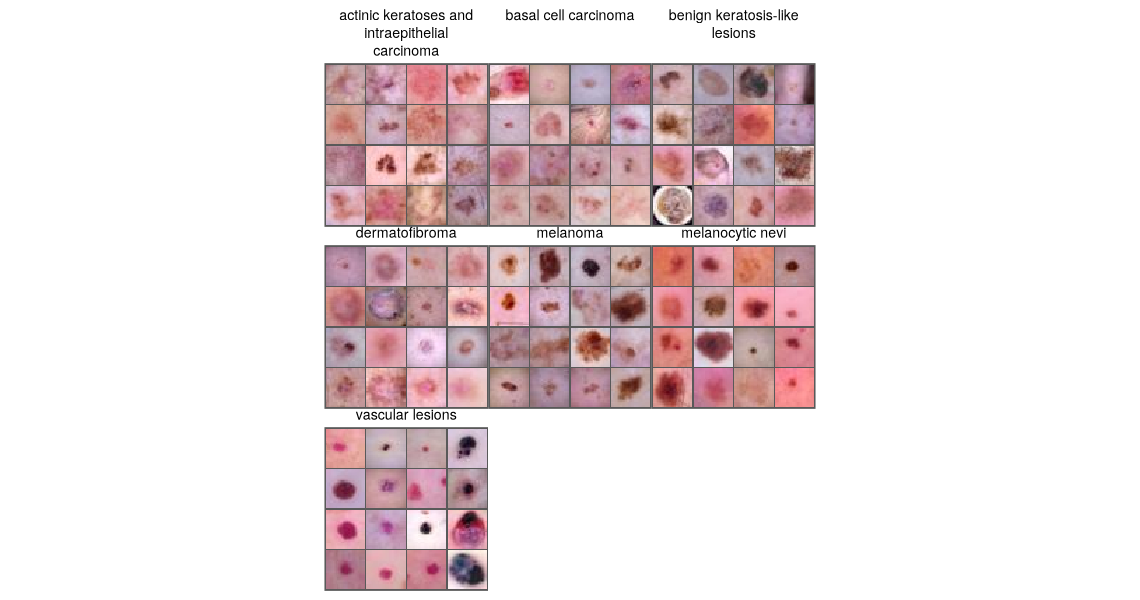

In [6]:
montage_grid(eda, root = RAIZ, ncol = 3)

Cor e padrão pigmentar são o sinal clínico, ao contrário do ultrassom do
BreastMNIST. A diferença de tom entre as classes vasculares e as pigmentadas
sugere que estatística de cor carrega informação.

## 4. Quanto a cor entrega de graça

In [7]:
data.frame(
  canal = c("R", "G", "B"),
  media = round(unlist(s$channel_mean), 4),
  desvio = round(unlist(s$channel_std), 4)
)

canal,media,desvio
<chr>,<dbl>,<dbl>
R,0.7631,0.1366
G,0.5381,0.1543
B,0.5614,0.1692


In [8]:
# factor() é obrigatório aqui; sem ele o lm trataria o rótulo como número.
r2 <- sapply(feats, function(v) {
  summary(lm(as.formula(paste(v, "~ factor(class_name)")), data = treino))$r.squared
})
round(r2, 3)

mean_intensity  std_intensity   nonzero_frac 
         0.054          0.177          0.003

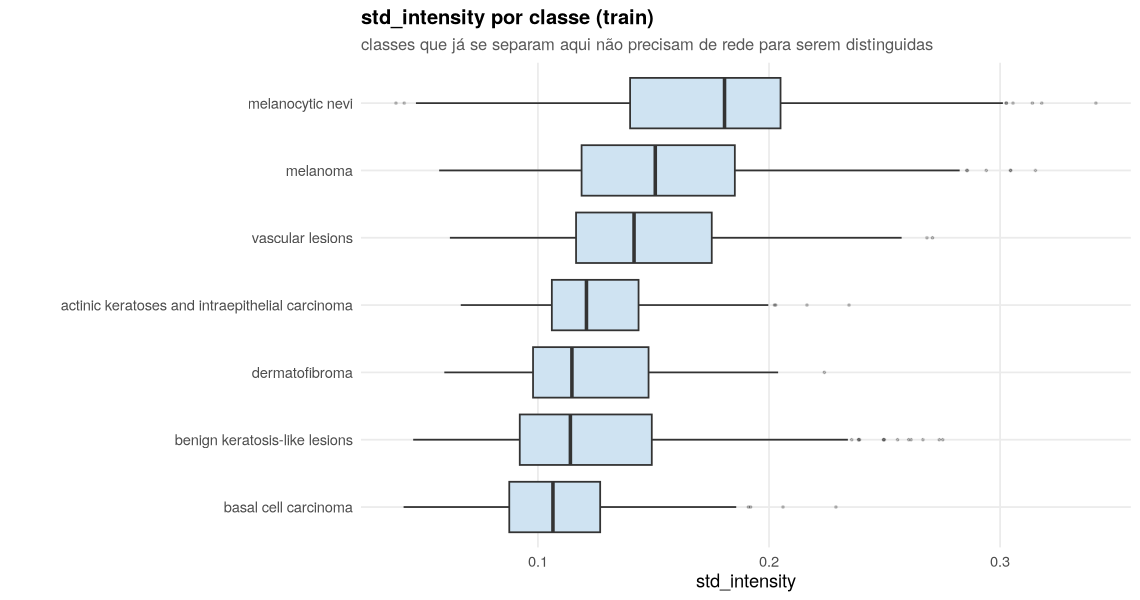

In [9]:
plot_feature_by_class(eda, "std_intensity", "train")

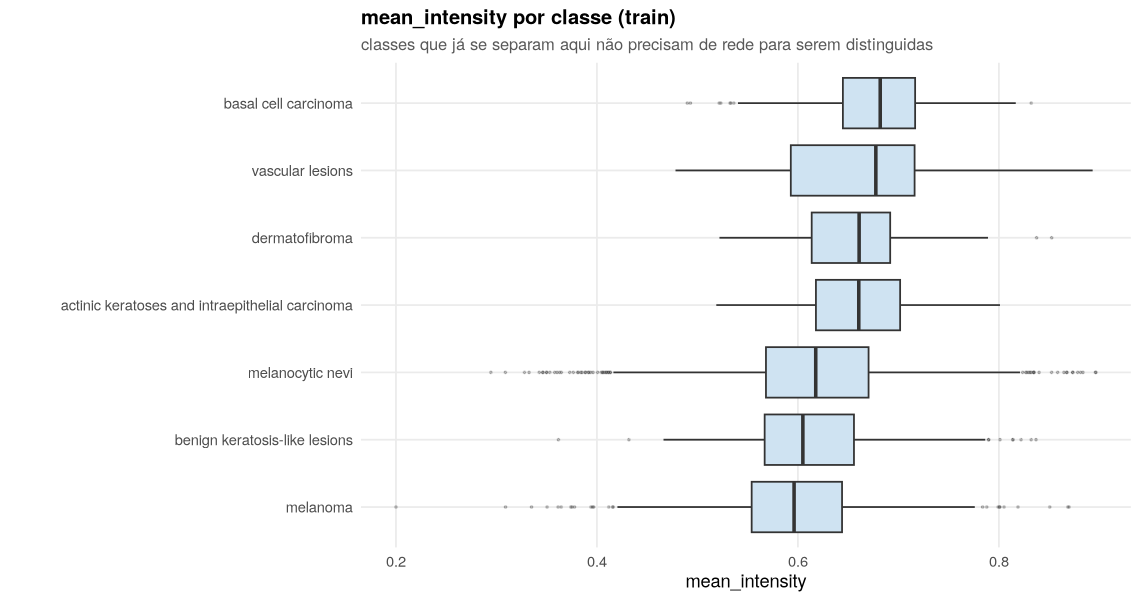

In [10]:
plot_feature_by_class(eda, "mean_intensity", "train")

`std_intensity` explica 18% da variância entre classes, contra 2% no BreastMNIST:
lesões pigmentadas têm contraste interno maior que pele adjacente uniforme.
`nonzero_frac` é inútil de novo (R² ~0,003), porque imagem dermatoscópica não tem
fundo vazio.

In [11]:
# O piso a superar: centroide nas três features, contra o chute na classe maior.
centroides <- treino |> group_by(class_name) |> summarise(across(all_of(feats), mean), .groups = "drop")
sds <- apply(as.matrix(treino[, feats]), 2, sd)
M <- sweep(as.matrix(teste[, feats]), 2, sds, "/")
C <- sweep(as.matrix(centroides[, feats]), 2, sds, "/")
dists <- sapply(seq_len(nrow(C)), function(i) rowSums((M - rep(C[i, ], each = nrow(M)))^2))
pred <- centroides$class_name[apply(dists, 1, which.min)]

bal <- mean(sapply(unique(teste$class_name), function(k) mean(pred[teste$class_name == k] == k)))
cat(sprintf("centroide (3 features): acurácia %.1f%% | balanced %.1f%%\n",
            100 * mean(pred == teste$class_name), 100 * bal))
cat(sprintf("chute na classe maior:  acurácia %.1f%% | balanced %.1f%%\n",
            100 * max(freq$p), 100 * (1 / s$num_classes)))

centroide (3 features): acurácia 41.1% | balanced 26.7%


chute na classe maior:  acurácia 67.0% | balanced 14.3%


As duas métricas contam histórias opostas, e por isso o par é reportado junto. O
chute ganha em acurácia e é o pior possível em balanced accuracy; o centroide
perde acurácia por tentar acertar as classes raras.

## 5. Os splits são comparáveis?

In [12]:
ex |>
  group_by(split) |>
  summarise(n = n(), across(all_of(feats), mean), .groups = "drop")

split,n,mean_intensity,std_intensity,nonzero_frac
<chr>,<int>,<dbl>,<dbl>,<dbl>
test,2005,0.6203063,0.1609763,0.9999266
train,7007,0.6208630,0.1591786,0.9999177
val,1003,0.6247616,0.1573956,0.9998800


In [13]:
ex |>
  count(split, class_name) |>
  group_by(split) |>
  mutate(p = 100 * n / sum(n)) |>
  ungroup() |>
  pivot_wider(id_cols = class_name, names_from = split, values_from = p) |>
  mutate(across(where(is.numeric), \(x) round(x, 1))) |>
  as.data.frame()

class_name,test,train,val
<chr>,<dbl>,<dbl>,<dbl>
actinic keratoses and intraepithelial carcinoma,3.3,3.3,3.3
basal cell carcinoma,5.1,5.1,5.2
benign keratosis-like lesions,11.0,11.0,11.0
dermatofibroma,1.1,1.1,1.2
melanocytic nevi,66.9,67.0,66.9
melanoma,11.1,11.1,11.1
vascular lesions,1.4,1.4,1.4


In [14]:
# A maior diferença de prevalência entre validação e teste, em pontos percentuais.
prev <- ex |>
  count(split, class_name) |>
  group_by(split) |>
  mutate(p = n / sum(n)) |>
  ungroup() |>
  select(split, class_name, p) |>
  pivot_wider(names_from = split, values_from = p)

cat(sprintf("maior divergência val vs teste: %.2f pp (classe '%s')\n",
            100 * max(abs(prev$val - prev$test)),
            prev$class_name[which.max(abs(prev$val - prev$test))]))

maior divergência val vs teste: 0.06 pp (classe 'melanoma')


Divergência máxima de 0,06 pontos percentuais entre validação e teste: o split
oficial foi estratificado, e a validação reproduz a prevalência do teste. Com 58x
de desbalanço, uma validação com prevalência diferente enviesaria a seleção para
o regime errado.

## O que fica

In [15]:
cat(sprintf("- %d classes, %d exemplos de treino, RGB\n", s$num_classes, s$n_examples$train))
cat(sprintf("- desbalanço %.1fx; piso de acurácia %.1f%%\n",
            s$train_imbalance_ratio, 100 * max(freq$p)))
cat(sprintf("- classe mais rara com %d exemplos de treino: limite de dado, não de modelo\n",
            min(freq$n)))
cat(sprintf("- R² de std_intensity: %.3f (cor/contraste carrega sinal, ao contrário do ultrassom)\n",
            r2[["std_intensity"]]))
cat("- reportar balanced accuracy e recall POR CLASSE, com intervalo; acurácia isolada é inútil aqui\n")

- 7 classes, 7007 exemplos de treino, RGB


- desbalanço 58.7x; piso de acurácia 67.0%


- classe mais rara com 80 exemplos de treino: limite de dado, não de modelo


- R² de std_intensity: 0.177 (cor/contraste carrega sinal, ao contrário do ultrassom)


- reportar balanced accuracy e recall POR CLASSE, com intervalo; acurácia isolada é inútil aqui


Comparado ao BreastMNIST: mais dados, mais classes, mais desbalanço, sinal de cor
aproveitável. Em ambos a acurácia é a métrica errada, e isso é decidido pelo dado,
antes de treinar.